# 3. Возможности Python по решению задачи линейной регрессии

Продемонстрируйте свое умение решать обе рассмотренные задачи с помощью методов fit и predict из sklearn.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data/ex1data1.txt', names=['Population', 'Profit'])
data

,Population,Profit
0,6.1101,17.59200
1,5.5277,9.13020
2,8.5186,13.66200
3,7.0032,11.85400
4,5.8598,6.82330
...,...,...
92,5.8707,7.20290
93,5.3054,1.98690
94,8.2934,0.14454
95,13.3940,9.05510


In [2]:
# noinspection PyShadowingNames
def computeCost(X: np.matrix, y: np.matrix, theta: np.matrix) -> float:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    j = X @ theta - y
    return (j.T @ j).item() / (2 * len(y))

In [3]:
from typing import Tuple, List


# noinspection PyShadowingNames
def gradientDescent(X: np.matrix, y: np.matrix, theta: np.matrix, alpha: float, iters: int) -> Tuple[np.matrix, List[float]]:
    iters_history: List[float] = list()
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    for i in range(iters):
        theta = theta - (alpha / len(y)) * X.T @ (X @ theta - y)
        iters_history.append(computeCost(X=X, y=y, theta=theta))
    return theta, iters_history

In [4]:
# noinspection PyTypeChecker, PyShadowingNames
def predict(X: np.matrix, theta: np.matrix) -> np.matrix:
    return X @ theta

In [5]:
X = np.column_stack([np.ones(len(data)), data['Population']])
y: np.matrix = data['Profit'].values
theta: np.matrix = np.zeros(shape=(2, 1))
alpha: float = 0.01
iters: int = 1000

# Process new theta and iters history
new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters)
print(f'new_theta = {new_theta[0].item(), new_theta[1].item()}')
print(f'J(new_theta) = {iters_history[-1]}')

new_theta = (-3.241402144274422, 1.1272942024281842)
J(new_theta) = 4.515955503078914


In [6]:
from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(X=X, y=y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


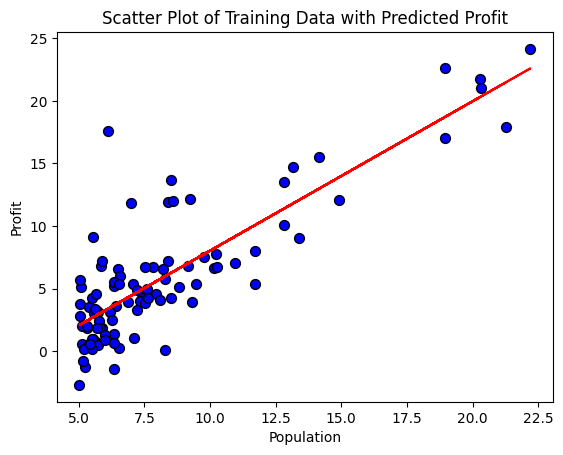

In [7]:
predictions = model.predict(X=X)
plt.scatter(data['Population'], data['Profit'], color='blue', marker='o', edgecolor='black', s=50)
plt.plot(data['Population'], predictions, color='red')
plt.xlabel('Population')
plt.ylabel('Profit')
plt.title('Scatter Plot of Training Data with Predicted Profit')
plt.show()

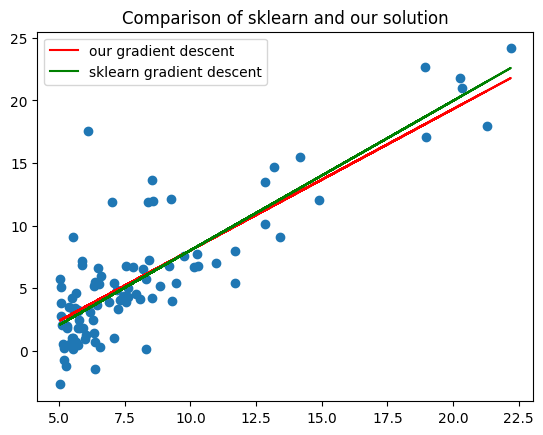

In [8]:
plt.title("Comparison of sklearn and our solution")
plt.scatter(data['Population'], data['Profit'])
plt.plot(data['Population'], predict(X=X, theta=new_theta), color='red', label='our gradient descent')
plt.plot(data['Population'], predictions, color='green', label='sklearn gradient descent')
plt.legend()
plt.show()